In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import  r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("student-scores.csv")

In [ ]:
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [ ]:

df.shape

(2000, 17)

In [ ]:
df.dtypes

,0
id,int64
first_name,object
last_name,object
email,object
gender,object
part_time_job,bool
absence_days,int64
extracurricular_activities,bool
weekly_self_study_hours,int64
career_aspiration,object


In [ ]:
df.isnull()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
id,0
first_name,0
last_name,0
email,0
gender,0
part_time_job,0
absence_days,0
extracurricular_activities,0
weekly_self_study_hours,0
career_aspiration,0


In [ ]:
numeric_df=df.select_dtypes(include=[np.number])
numeric_df.head()

scaler=StandardScaler()
scaled_data=scaler.fit_transform(numeric_df)
print("scaled data shape:",scaled_data.shape)

scaled data shape: (2000, 10)


In [ ]:
numeric_df.dtypes

,0
id,int64
absence_days,int64
weekly_self_study_hours,int64
math_score,int64
history_score,int64
physics_score,int64
chemistry_score,int64
biology_score,int64
english_score,int64
geography_score,int64


In [ ]:
pca = PCA(n_components=9)
pca_data = pca.fit_transform(scaled_data)

y = numeric_df['math_score']
X = pca_data

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (2000, 9)
Shape of target (y): (2000,)


In [ ]:
y_class = np.where(y >= 50, 1, 0)  # 1 = pass, 0 = fail



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 9)
X_test shape: (400, 9)
y_train shape: (1600,)
y_test shape: (400,)


without pca accuracy

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)

print(f"R-squared score using PCA components to predict math_score: {r2:.4f}")

R-squared score using PCA components to predict math_score: 0.8837


In [ ]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predict classes
y_pred = clf.predict(X_test)


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[ 0  0  0 ...  0  0  0]
 [ 1  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  1  5  1]
 [ 0  0  0 ...  0  8  3]
 [ 0  0  0 ...  0 12  3]]


with pca

In [ ]:
pca=PCA(n_components=9)
pca_data=pca.fit_transform(scaled_data)
print(pca.explained_variance_ratio_)
print("total variance :",sum(pca.explained_variance_ratio_))
print("total accuracy :",round(sum(pca.explained_variance_ratio_)*100,2),"%")

[0.21594849 0.10830145 0.10162098 0.10038926 0.09179856 0.08654656
 0.08507153 0.0817137  0.07479385]
total variance : 0.9461843859598655
total accuracy : 94.62 %


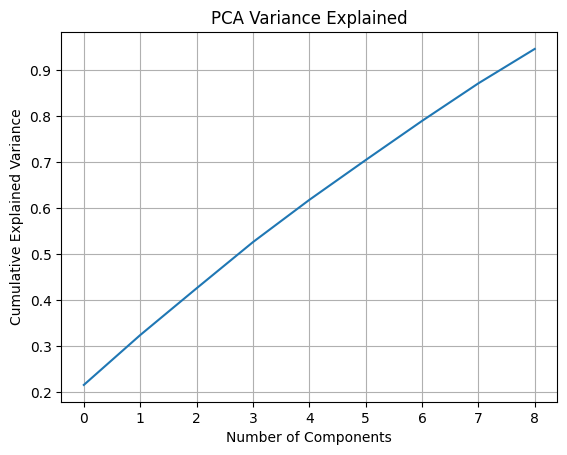

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Explained')
plt.grid(True)
plt.show()

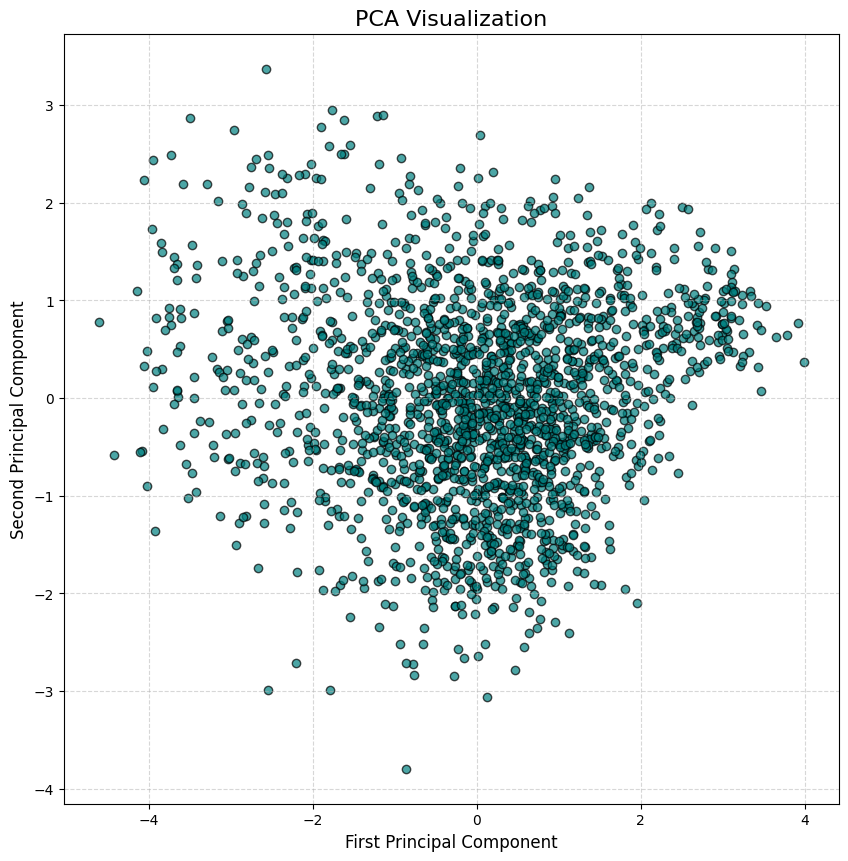

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.scatter(pca_data[:,0], pca_data[:,1], color='teal', alpha=0.7, edgecolors='k')

plt.title("PCA Visualization", fontsize=16)
plt.xlabel("First Principal Component", fontsize=12)
plt.ylabel("Second Principal Component", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [ ]:
indices = [2, 5, 10]
for i in indices:
    pc1 = pca_data[i,0]
    pc2 = pca_data[i,1]
    dominant = "PC1" if abs(pc1) > abs(pc2) else "PC2"
    print(f"Point {i}: PC1={pc1:.3f}, PC2={pc2:.3f} → Dominant: {dominant}")


Point 2: PC1=-0.107, PC2=1.106 → Dominant: PC2
Point 5: PC1=0.847, PC2=-1.572 → Dominant: PC2
Point 10: PC1=-1.124, PC2=0.018 → Dominant: PC1


scree plot

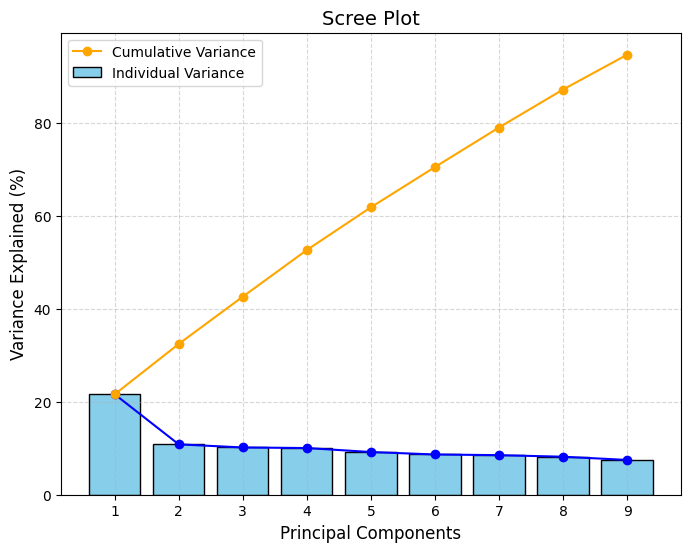

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

explained_var = pca.explained_variance_ratio_ * 100
components = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(8,6))
plt.bar(components, explained_var, color='skyblue', edgecolor='k', label='Individual Variance')
plt.plot(components, explained_var, marker='o', color='blue')

cum_var = np.cumsum(explained_var)
plt.plot(components, cum_var, marker='o', color='orange', label='Cumulative Variance')

plt.title("Scree Plot", fontsize=14)
plt.xlabel("Principal Components", fontsize=12)
plt.ylabel("Variance Explained (%)", fontsize=12)
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()
